In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"namakpaara","key":"b6815ca05d17fe0745fdf48abda673e3"}'}

In [3]:
# Step 1: Set up Kaggle API credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)

# Assuming 'kaggle.json' is uploaded to the root directory of Colab environment
!cp kaggle.json /root/.kaggle/
os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle competitions download -c isic-2024-challenge

100% 2.00G/2.00G [01:47<00:00, 17.0MB/s]
100% 2.00G/2.00G [01:47<00:00, 20.0MB/s]


In [5]:
!unzip isic-2024-challenge.zip

Streaming output truncated to the last 5000 lines.
  inflating: train-image/image/ISIC_9874656.jpg  
  inflating: train-image/image/ISIC_9874659.jpg  
  inflating: train-image/image/ISIC_9874663.jpg  
  inflating: train-image/image/ISIC_9874742.jpg  
  inflating: train-image/image/ISIC_9874751.jpg  
  inflating: train-image/image/ISIC_9874803.jpg  
  inflating: train-image/image/ISIC_9874805.jpg  
  inflating: train-image/image/ISIC_9874832.jpg  
  inflating: train-image/image/ISIC_9874878.jpg  
  inflating: train-image/image/ISIC_9874897.jpg  
  inflating: train-image/image/ISIC_9874925.jpg  
  inflating: train-image/image/ISIC_9874931.jpg  
  inflating: train-image/image/ISIC_9874939.jpg  
  inflating: train-image/image/ISIC_9874940.jpg  
  inflating: train-image/image/ISIC_9874963.jpg  
  inflating: train-image/image/ISIC_9874987.jpg  
  inflating: train-image/image/ISIC_9875007.jpg  
  inflating: train-image/image/ISIC_9875010.jpg  
  inflating: train-image/image/ISIC_9875033.jpg  

In [6]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from imblearn.over_sampling import SMOTE
import seaborn as sns

In [7]:
# Paths to dataset
metadata_path = '/content/train-metadata.csv'
image_folder_path = '/content/train-image/image'

In [8]:
# Load metadata
metadata = pd.read_csv(metadata_path, low_memory=False)
print("Metadata Loaded:")
print(metadata.head())

Metadata Loaded:
        isic_id  target  patient_id  age_approx   sex anatom_site_general  \
0  ISIC_0015670       0  IP_1235828        60.0  male     lower extremity   
1  ISIC_0015845       0  IP_8170065        60.0  male           head/neck   
2  ISIC_0015864       0  IP_6724798        60.0  male     posterior torso   
3  ISIC_0015902       0  IP_4111386        65.0  male      anterior torso   
4  ISIC_0024200       0  IP_8313778        55.0  male      anterior torso   

   clin_size_long_diam_mm          image_type tbp_tile_type   tbp_lv_A  ...  \
0                    3.04  TBP tile: close-up     3D: white  20.244422  ...   
1                    1.10  TBP tile: close-up     3D: white  31.712570  ...   
2                    3.40  TBP tile: close-up        3D: XP  22.575830  ...   
3                    3.22  TBP tile: close-up        3D: XP  14.242329  ...   
4                    2.73  TBP tile: close-up     3D: white  24.725520  ...   

    lesion_id  iddx_full  iddx_1  iddx_2  idd

In [9]:
metadata

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,0,IP_1140263,70.0,male,anterior torso,6.80,TBP tile: close-up,3D: XP,22.574335,...,IL_9520694,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999988
401055,ISIC_9999951,0,IP_5678181,60.0,male,posterior torso,3.11,TBP tile: close-up,3D: white,19.977640,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999820
401056,ISIC_9999960,0,IP_0076153,65.0,female,anterior torso,2.05,TBP tile: close-up,3D: XP,17.332567,...,IL_9852274,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.999416
401057,ISIC_9999964,0,IP_5231513,30.0,female,anterior torso,2.80,TBP tile: close-up,3D: XP,22.288570,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000


In [10]:
print("\nOriginal Class Distribution:")
print(metadata['target'].value_counts())


Original Class Distribution:
target
0    400666
1       393
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='count'>

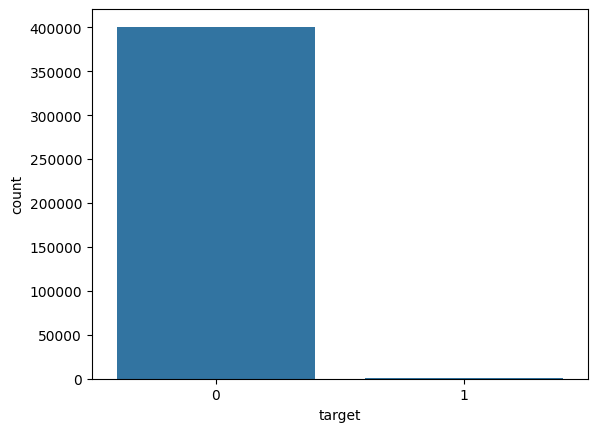

In [11]:
sns.countplot(data=metadata, x='target')

In [12]:
from sklearn.utils import resample

In [13]:
# Perform downsampling to balance the dataset (equal number of malignant and benign samples)
malignant = metadata[metadata['target'] == 1]
benign = metadata[metadata['target'] == 0]

In [14]:
benign_downsample=resample(benign,replace=True, n_samples=len(malignant),random_state=42)

In [15]:
downsampled_data=pd.concat([malignant,benign_downsample])

In [16]:
# Check the distribution after downsampling
print("Downsampled Data Distribution:")
print(downsampled_data['target'].value_counts())

Downsampled Data Distribution:
target
1    393
0    393
Name: count, dtype: int64


In [17]:
# Image generator to load and preprocess images in batches
def image_generator(metadata, image_folder_path, batch_size=32):
    X_batch = []
    y_batch = []

    for index, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Loading Images"):
        image_name = f"{row['isic_id']}.jpg"
        label = row['target']
        image_path = os.path.join(image_folder_path, image_name)

        # Load and preprocess image
        if os.path.exists(image_path):
            image = load_img(image_path, color_mode='grayscale', target_size=(64, 64))
            image_array = img_to_array(image)
            image_flattened = image_array.flatten()

            X_batch.append(image_flattened)
            y_batch.append(label)

        # Yield batch if it's full
        if len(X_batch) == batch_size:
            yield np.array(X_batch), np.array(y_batch)
            X_batch, y_batch = [], []  # Reset the batch lists for the next batch

In [18]:
# Prepare data for training and evaluation using downsampled data
# Split the data into training and testing sets
X = []
y = []

In [19]:
for index, row in downsampled_data.iterrows():
    image_name = f"{row['isic_id']}.jpg"
    label = row['target']
    image_path = os.path.join(image_folder_path, image_name)

    if os.path.exists(image_path):
        # Load and preprocess the image
        image = load_img(image_path, color_mode='grayscale', target_size=(64, 64))
        image_array = img_to_array(image)
        image_flattened = image_array.flatten()

        X.append(image_flattened)
        y.append(label)


In [20]:
# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LGBM


In [22]:
! pip install lightgbm

In [23]:
import lightgbm as lgb

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Convert training data to lgbm based dataset.

In [24]:
d_train=lgb.Dataset(X_train,label=y_train)

This will convert data to lgbm compatible dataset.

In [25]:
params = {}
params['learning_rate'] = 0.002
params['boosting_type'] = 'gbdt' # dart
params['objective'] = 'binary'
params['metric'] = 'binary_logloss'
params['sub_feature'] = 0.5
params['num_leaves'] = 10
params['min_data'] = 50
params['max_depth'] = 10

In [26]:
clf=lgb.train(params, d_train, 1400)

[LightGBM] [Info] Number of positive: 316, number of negative: 312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 443498
[LightGBM] [Info] Number of data points in the train set: 628, number of used features: 4096
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503185 -> initscore=0.012739
[LightGBM] [Info] Start training from score 0.012739
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [27]:
#Prediction
y_pred=clf.predict(X_test)

In [28]:
predictions = [round(value) for value in y_pred]

In [29]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.71      0.72      0.71        81
           1       0.70      0.69      0.69        77

    accuracy                           0.70       158
   macro avg       0.70      0.70      0.70       158
weighted avg       0.70      0.70      0.70       158



# Performing Hyper parameter tuning

In [30]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

# Create a basic LGBM model
lgbm = lgb.LGBMClassifier()

# Define a grid of hyperparameters for random search
param_dist = {
    'num_leaves': np.arange(10, 400, 10),
    'max_depth': np.arange(3, 50, 2),
    'learning_rate': [0.001, 0.003, 0.01, 0.03, 0.1],
    'n_estimators': np.arange(100, 1200, 100),
    'subsample': np.linspace(0.5, 1.0, 5),
    'colsample_bytree': np.linspace(0.5, 1.0, 5)
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,              # Number of parameter settings sampled
    scoring='accuracy',     # Adjust based on your metric of choice (e.g., 'roc_auc')
    cv=2,                   # Number of cross-validation folds
    verbose=2,              # Verbosity level
    random_state=42,        # Ensures reproducibility
    n_jobs=-1               # Use all available cores
)

# Fit the model with training data (replace X_train and y_train with your data)
random_search.fit(X_train, y_train)

# Get the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score: ", random_search.best_score_)



Fitting 2 folds for each of 50 candidates, totalling 100 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 316, number of negative: 312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 443498
[LightGBM] [Info] Number of data points in the train set: 628, number of used features: 4096
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503185 -> initscore=0.012739
[LightGBM] [Info] Start training from score 0.012739
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [31]:
params = {}
params['learning_rate'] = 0.01
params['num_leaves'] = 190
params['subsample'] = 0.875
params['n_estimators'] = 500
params['max_depth'] = 9
params['colsample_bytree'] = 0.5

In [32]:
clf=lgb.train(params, d_train, 1400)

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 443498
[LightGBM] [Info] Number of data points in the train set: 628, number of used features: 4096
[LightGBM] [Info] Start training from score 0.503185
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [33]:
#Prediction
y_pred=clf.predict(X_test)

In [34]:
predictions = [round(value) for value in y_pred]

In [35]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.71      0.74      0.73        81
           1       0.72      0.69      0.70        77

    accuracy                           0.72       158
   macro avg       0.72      0.71      0.71       158
weighted avg       0.72      0.72      0.71       158



Text(0, 0.5, 'True Positive Rate')

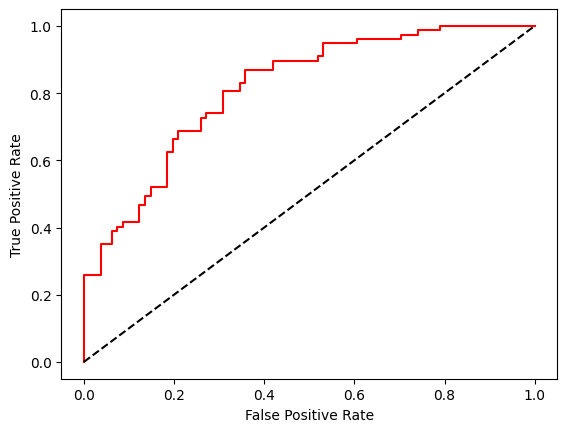

In [36]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_pred)

auc = roc_auc_score(y_test, y_pred)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


The effectiveness of the model depends on the AUC value. Although visually it seems moderate (likely between 0.70 and 0.85). This suggests the model has acceptable performance.